# **Confusion Matrix**



##  What is a Confusion Matrix?

A **Confusion Matrix** is a table used to **evaluate the performance of a classification model**.  
It compares the **actual labels** (ground truth) with the **predicted labels** from your model.

It helps us answer:
- How many predictions were **correct**?
- Where did the model **make mistakes** (false positives or false negatives)?
- How does the model perform for **each class individually**?

---

##  Structure of a Confusion Matrix (for Binary Classification)

|                      | **Predicted: Positive** | **Predicted: Negative** |
|----------------------|-------------------------|-------------------------|
| **Actual: Positive** | True Positive (TP)      | False Negative (FN)     |
| **Actual: Negative** | False Positive (FP)     | True Negative (TN)      |

### Meaning of each cell:
- **True Positive (TP)** → Model correctly predicted *Positive* class  
- **True Negative (TN)** → Model correctly predicted *Negative* class  
- **False Positive (FP)** → Model incorrectly predicted *Positive* (Type I Error)  
- **False Negative (FN)** → Model incorrectly predicted *Negative* (Type II Error)  

---

##  Confusion Matrix Equation Form

We can represent it as:

\[
\text{Confusion Matrix} =
\begin{bmatrix}
TP & FP \\
FN & TN
\end{bmatrix}
\]

Each element in the matrix counts how many times a particular combination of **actual vs predicted** labels occurs.

---

##  Key Metrics Derived from the Confusion Matrix

Once you have TP, TN, FP, and FN, you can compute many useful metrics:

### 1. Accuracy
Fraction of total predictions that are correct.

$$
Accuracy = \frac{TP + TN}{TP + TN + FP + FN}
$$

### 2. Precision (Positive Predictive Value)
Fraction of predicted positives that are actually positive.

$$
Precision = \frac{TP}{TP + FP}
$$

### 3. Recall (Sensitivity or True Positive Rate)
Fraction of actual positives that were correctly predicted.

$$
Recall = \frac{TP}{TP + FN}
$$

### 4. F1 Score
Harmonic mean of Precision and Recall.

$$
F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}
$$

---

##  Why Do We Need It?

Accuracy alone can be misleading — especially when classes are **imbalanced**.  
For example:
- If 95% of samples are “negative,” predicting *all negatives* gives 95% accuracy, but **the model learns nothing**.

A confusion matrix shows *how the model performs on each class*, making it essential for:
- Medical diagnoses (False negatives are critical)
- Spam detection
- Fraud detection
- Sentiment analysis
- Any classification problem where **error type matters**

---

##  Example for Intuition

Imagine a spam detector:
- Model predicts **Spam** or **Not Spam**
- You test it on 100 emails:
  - 60 were truly spam
  - 40 were not spam

Model results:
- 50 spam correctly identified → **TP = 50**
- 10 spam missed → **FN = 10**
- 5 non-spam wrongly labeled as spam → **FP = 5**
- 35 non-spam correctly identified → **TN = 35**

So, the confusion matrix is:

|                      | **Predicted Spam** | **Predicted Not Spam** |
|----------------------|--------------------|-------------------------|
| **Actual Spam**      | 50 (TP)            | 10 (FN)                 |
| **Actual Not Spam**  | 5 (FP)             | 35 (TN)                 |

This matrix reveals:
- The model is good but still misclassifies 10 spam emails and 5 normal emails.

---

##  When to Use
Use a Confusion Matrix whenever:
- You are dealing with **classification tasks**
- You want to understand **error distribution**
- You need to calculate **precision, recall, or F1 score**


# **Generating & Visulaizing Dataset**

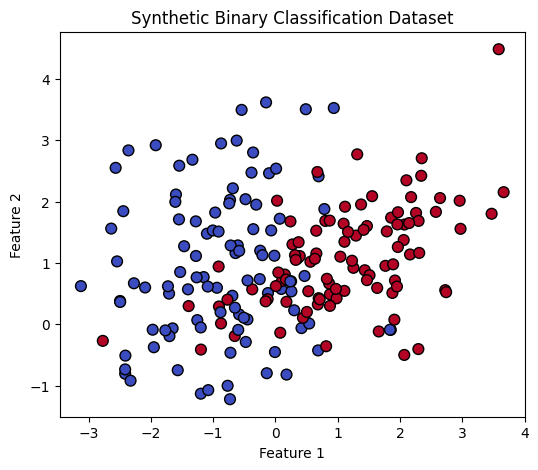

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=200, n_features=2, n_redundant=0,
                           n_clusters_per_class=1, random_state=42)


plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', edgecolor='k', s=60)
plt.title("Synthetic Binary Classification Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# **Implementation**

In [2]:
def confusion_matrix_custom(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))

    return np.array([[TP, FP],
                     [FN, TN]])

In [3]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X, y)

y_pred = model.predict(X)

In [4]:
cm = confusion_matrix_custom(y, y_pred)
print(" Confusion Matrix (Custom):")
print(cm)

 Confusion Matrix (Custom):
[[85 17]
 [15 83]]


In [5]:
from sklearn.metrics import confusion_matrix

cm_sklearn = confusion_matrix(y, y_pred)
print(" Confusion Matrix (Sklearn):")
print(cm_sklearn)

 Confusion Matrix (Sklearn):
[[83 17]
 [15 85]]


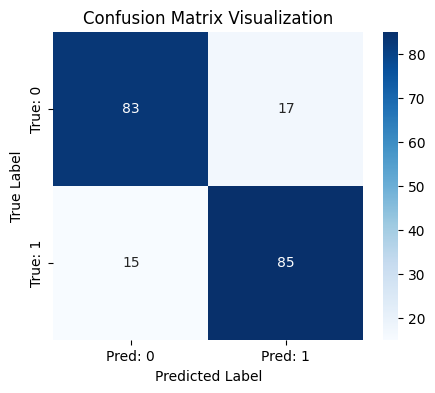

In [6]:
import seaborn as sns

plt.figure(figsize=(5,4))
sns.heatmap(cm_sklearn, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred: 0", "Pred: 1"],
            yticklabels=["True: 0", "True: 1"])
plt.title("Confusion Matrix Visualization")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()